In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
pearson_path = Path("../outputs/similarity_correlation/pearson.npy")
spearman_path = Path("../outputs/similarity_correlation/spearman.npy")

pearson_sim = np.load(pearson_path)
spearman_sim = np.load(spearman_path)

## 1. Remove Self-Correlation

The diagonal of each similarity matrix is always 1.0 (a protein correlated with itself).
We mask it out so it does not skew any downstream statistics or plots.

In [3]:
pearson_no_diag  = pearson_sim.copy()
spearman_no_diag = spearman_sim.copy()

np.fill_diagonal(pearson_no_diag,  np.nan)
np.fill_diagonal(spearman_no_diag, np.nan)

print(f"Matrix shape: {pearson_no_diag.shape}")
print(f"Diagonal entries set to NaN. Total cells: {pearson_no_diag.size:,} | Off-diagonal: {pearson_no_diag.size - len(pearson_no_diag):,}")

Matrix shape: (12142, 12142)
Diagonal entries set to NaN. Total cells: 147,428,164 | Off-diagonal: 147,416,022


In [4]:
overlap_path = Path("../data/processed/protein_overlap.npy")
overlap_matrix = np.load(overlap_path)
print(f"Overlap matrix shape: {overlap_matrix.shape}")
print(f"Overlap matrix stats: min={np.nanmin(overlap_matrix)}, max={np.nanmax(overlap_matrix)}, mean={np.nanmean(overlap_matrix):.2f}, median={np.nanmedian(overlap_matrix)}")  

Overlap matrix shape: (12142, 12142)
Overlap matrix stats: min=0, max=118, mean=82.78, median=118.0


## 2. Range of Correlations

Check min, max, mean, and how many pairs are NaN (proteins with no jointly observed patients).

In [5]:
def range_summary(name: str, mat: np.ndarray) -> None:
    vals  = mat.flatten()
    valid = vals[~np.isnan(vals)]
    n_nan = np.isnan(vals).sum()
    print(f"── {name} ──")
    print(f"  Valid pairs : {len(valid):,}  |  NaN pairs: {n_nan:,}")
    print(f"  Min  : {valid.min():.4f}")
    print(f"  Max  : {valid.max():.4f}")
    print(f"  Mean : {valid.mean():.4f}")
    print(f"  Std  : {valid.std():.4f}")
    print(f"  Median: {np.median(valid):.4f}")
    print()

range_summary("Pearson  (no diagonal)", pearson_no_diag)
range_summary("Spearman (no diagonal)", spearman_no_diag)

── Pearson  (no diagonal) ──
  Valid pairs : 127,363,674  |  NaN pairs: 20,064,490
  Min  : -0.9546
  Max  : 0.9961
  Mean : 0.0023
  Std  : 0.2227
  Median: -0.0037

── Spearman (no diagonal) ──
  Valid pairs : 127,363,674  |  NaN pairs: 20,064,490
  Min  : -0.9445
  Max  : 0.9938
  Mean : 0.0007
  Std  : 0.2219
  Median: -0.0036



## 3. Distribution of Correlations

Plot the histogram of off-diagonal correlation values for both Pearson and Spearman.
We use only the upper triangle to avoid counting each pair twice.

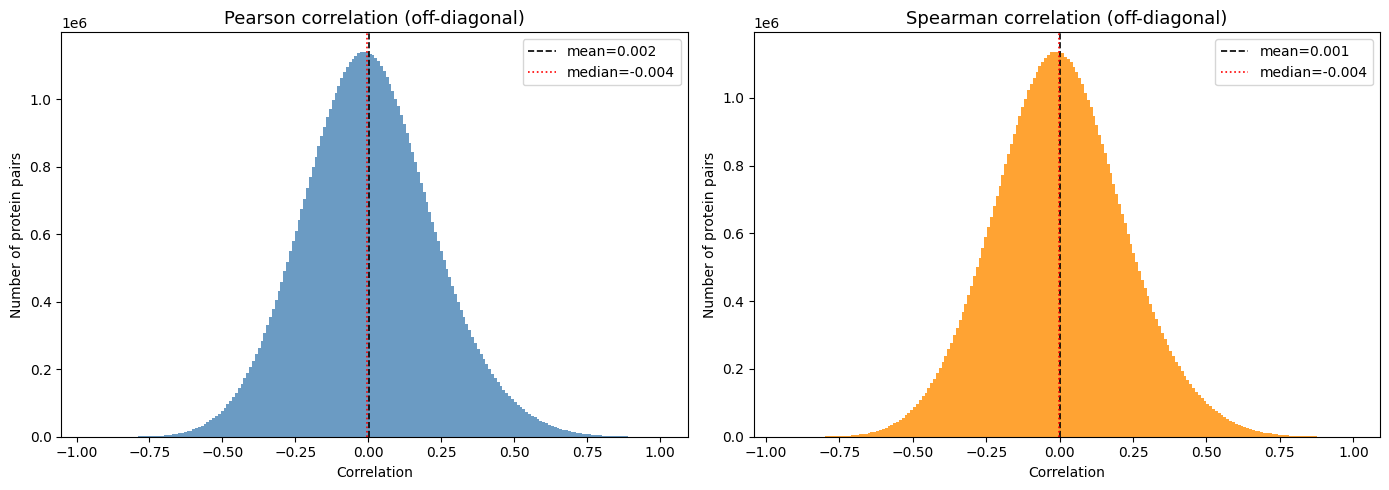

In [6]:
import matplotlib.pyplot as plt

n = len(pearson_no_diag)
triu_idx = np.triu_indices(n, k=1)

pearson_vals  = pearson_no_diag[triu_idx]
spearman_vals = spearman_no_diag[triu_idx]

pearson_valid  = pearson_vals[~np.isnan(pearson_vals)]
spearman_valid = spearman_vals[~np.isnan(spearman_vals)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, vals, name, color in zip(
    axes,
    [pearson_valid, spearman_valid],
    ["Pearson", "Spearman"],
    ["steelblue", "darkorange"],
):
    ax.hist(vals, bins=200, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(vals.mean(),   color="black",  linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.3f}")
    ax.axvline(np.median(vals), color="red", linestyle=":",  linewidth=1.2, label=f"median={np.median(vals):.3f}")
    ax.set_title(f"{name} correlation (off-diagonal)", fontsize=13)
    ax.set_xlabel("Correlation")
    ax.set_ylabel("Number of protein pairs")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/correlation_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

This is standard normal distribution!

## 4. Heatmap — First 100 × 100 Proteins

A split-triangle heatmap of the top-left 100 × 100 protein block:

- **Upper triangle** — correlation value (red = positive, blue = negative)
- **Lower triangle** — number of jointly observed patients (yellow → red = low → high)
- **Diagonal** — masked white (self-correlation removed)

The two metrics together let you immediately spot whether a high or low correlation is supported by many patients or just a handful.

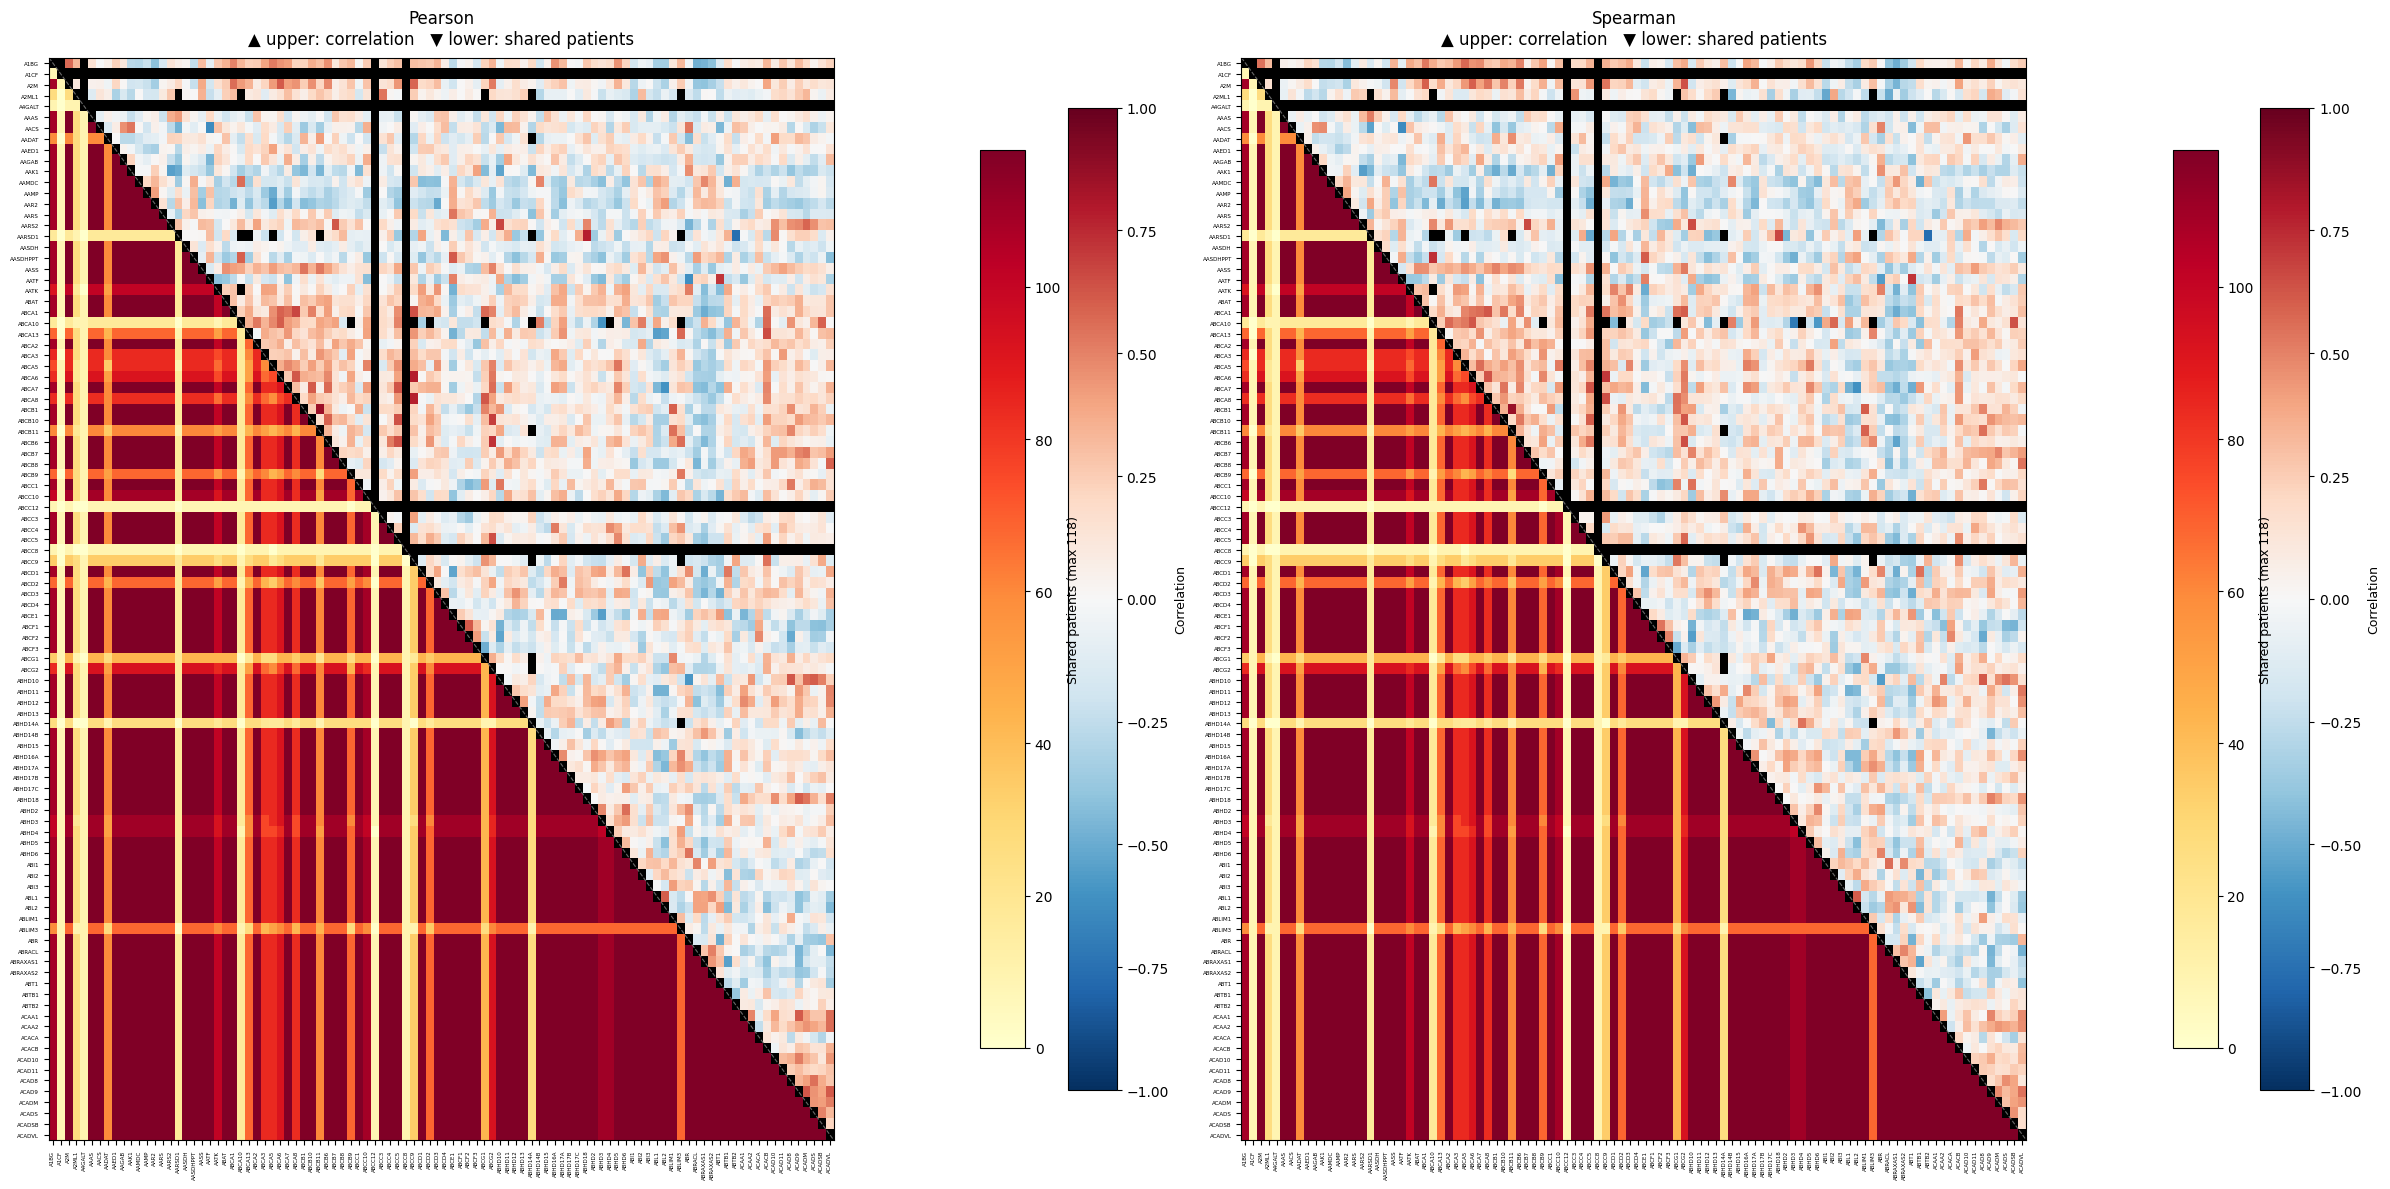

In [7]:
import matplotlib.pyplot as plt

protein_index = pd.read_csv(
    "../outputs/similarity_correlation/protein_index.csv"
)["0"].tolist()

N_SHOW = 100
labels = protein_index[:N_SHOW]

# Slice blocks; convert overlap to float so we can assign NaN to diagonal
pearson_block  = pearson_no_diag[:N_SHOW, :N_SHOW]
spearman_block = spearman_no_diag[:N_SHOW, :N_SHOW]
overlap_block  = overlap_matrix[:N_SHOW, :N_SHOW].astype(np.float32).copy()
np.fill_diagonal(overlap_block, np.nan)

# Boolean masks — True where we WANT to show each metric
upper_mask = np.zeros((N_SHOW, N_SHOW), dtype=bool)
upper_mask[np.triu_indices(N_SHOW, k=1)] = True   # i < j  → correlation

lower_mask = np.zeros((N_SHOW, N_SHOW), dtype=bool)
lower_mask[np.tril_indices(N_SHOW, k=-1)] = True  # i > j  → overlap

# Colormaps
# Layer 1 (correlation): bad = black  → diagonal and lower triangle render white
# Layer 2 (overlap)    : bad = none   → transparent, lets layer 1 show through
cmap_corr    = plt.cm.RdBu_r.copy();   cmap_corr.set_bad("black")
cmap_overlap = plt.cm.YlOrRd.copy();   cmap_overlap.set_bad("none")

max_overlap = int(overlap_matrix.max())

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

for ax, corr_blk, title in zip(
    axes,
    [pearson_block, spearman_block],
    ["Pearson", "Spearman"],
):
    # Mask each metric to its own triangle
    corr_upper    = np.ma.masked_where(~upper_mask, corr_blk)
    overlap_lower = np.ma.masked_where(~lower_mask, overlap_block)

    # Layer 1: correlation fills the upper triangle (lower + diag → white)
    im_corr    = ax.imshow(corr_upper,    cmap=cmap_corr,
                           vmin=-1, vmax=1, aspect="auto")
    # Layer 2: overlap fills the lower triangle (upper + diag → transparent)
    im_overlap = ax.imshow(overlap_lower, cmap=cmap_overlap,
                           vmin=0, vmax=max_overlap, aspect="auto")

    # Dashed diagonal to visually separate the two halves
    ax.plot([-0.5, N_SHOW - 0.5], [-0.5, N_SHOW - 0.5],
            color="dimgray", linewidth=0.8, linestyle="--")

    ax.set_title(
        f"{title}\n▲ upper: correlation   ▼ lower: shared patients",
        fontsize=12, pad=10,
    )
    ax.set_xticks(range(N_SHOW))
    ax.set_yticks(range(N_SHOW))
    ax.set_xticklabels(labels, rotation=90, fontsize=4)
    ax.set_yticklabels(labels, fontsize=4)

    cb1 = plt.colorbar(im_corr,    ax=ax, fraction=0.046, pad=0.04)
    cb1.set_label("Correlation", fontsize=9)

    cb2 = plt.colorbar(im_overlap, ax=ax, fraction=0.046, pad=0.15)
    cb2.set_label(f"Shared patients (max {max_overlap})", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/heatmap_top100.png", dpi=150, bbox_inches="tight")
plt.show()

# Baseline Similarity: Pearson & Spearman

### NaN Strategy
NaN = protein not detected in that patient — biologically meaningful absence.
Treating NaN as 0 is incorrect: 0 in log₂ space implies ratio = 1 (no change), not absence.

Each protein pair uses only **jointly observed patients** (pairwise complete observations).
No imputation is performed.

### Why `min_patients = 10`
- N=2 → correlation is always exactly ±1 by definition (uninformative)
- N<10 → high variance; a single outlier patient can dominate the estimate
- 10/118 ≈ 8.5% of patients — a reasonable statistical floor without discarding too many sparse pairs

Inspect the overlap distribution to verify this choice:
```python
vals = overlap[np.triu_indices(len(overlap), k=1)]
for t in [5, 10, 20, 30]:
    print(f"min_patients={t}: {(vals >= t).mean()*100:.1f}% pairs retained")
```

### NaN in Output Matrices
Pairs below `min_patients` are set to NaN — meaning **"insufficient evidence"**, not "no interaction".

- **Saved matrices**: NaN preserved — never conflate unevaluable pairs with zero correlation
- **PPI ranking**: NaN pairs filtered out — only evaluable pairs enter the ranked table
- **Dense methods** (spectral clustering, kernel PCA): fill with 0 at method boundary only
  (`np.nan_to_num(sim, nan=0.0)`) — neutral, not asserting similarity or dissimilarity

### Spearman Approximation
Ranks are computed per protein over its own observed patients, not the jointly observed
subset per pair. Exact per-pair ranking is O(P²) — impractical at 12k proteins.
Bias is negligible for proteins observed in many patients; interpret sparse proteins (<20 observed) with caution.

In [8]:
ae_cosine_path = Path("../outputs/similarity_autoencoder/autoencoder_cosine.npy")
transformer_cosine_path = Path("../outputs/similarity_transformer/transformer_cosine.npy")

ae_cosine = np.load(ae_cosine_path)
transformer_cosine = np.load(transformer_cosine_path)

ae_cosine_no_diag  = ae_cosine.copy()
transformer_cosine_no_diag = transformer_cosine.copy()

np.fill_diagonal(ae_cosine_no_diag,  np.nan)
np.fill_diagonal(transformer_cosine_no_diag, np.nan)

range_summary("AE  (no diagonal)", ae_cosine_no_diag)
range_summary("Transformer (no diagonal)", transformer_cosine_no_diag)


── AE  (no diagonal) ──
  Valid pairs : 147,416,022  |  NaN pairs: 12,142
  Min  : -0.7236
  Max  : 0.9990
  Mean : 0.1618
  Std  : 0.2346
  Median: 0.1602

── Transformer (no diagonal) ──
  Valid pairs : 147,416,022  |  NaN pairs: 12,142
  Min  : -0.6520
  Max  : 0.9993
  Mean : 0.3229
  Std  : 0.2519
  Median: 0.3247



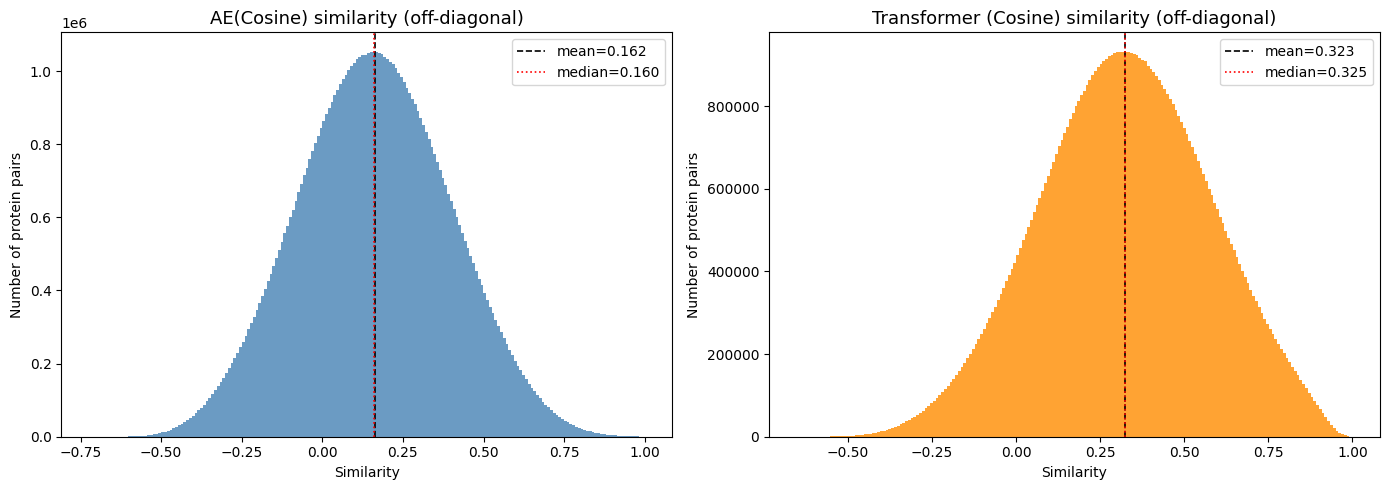

In [9]:
import matplotlib.pyplot as plt

n = len(ae_cosine_no_diag)
triu_idx = np.triu_indices(n, k=1)

ae_vals  = ae_cosine_no_diag[triu_idx]
transformer_vals = transformer_cosine_no_diag[triu_idx]

ae_valid  = ae_vals[~np.isnan(ae_vals)]
transformer_valid = transformer_vals[~np.isnan(transformer_vals)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, vals, name, color in zip(
    axes,
    [ae_valid, transformer_valid],
    ["AE(Cosine)", "Transformer (Cosine)"],
    ["steelblue", "darkorange"],
):
    ax.hist(vals, bins=200, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(vals.mean(),   color="black",  linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.3f}")
    ax.axvline(np.median(vals), color="red", linestyle=":",  linewidth=1.2, label=f"median={np.median(vals):.3f}")
    ax.set_title(f"{name} similarity (off-diagonal)", fontsize=13)
    ax.set_xlabel("Similarity")
    ax.set_ylabel("Number of protein pairs")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/cosine_similarity_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## CORUM Based Metrics Analysis

In [10]:
eval_dir = Path("../outputs/evaluation_CORUM")

metrics_df = pd.read_csv(eval_dir / "method_comparison_metrics.csv")
atk_df     = pd.read_csv(eval_dir / "precision_enrichment_at_k.csv")
complex_df = pd.read_csv(eval_dir / "complex_level_validation.csv")

# Short labels shown on all plots
LABELS = {
    "pearson":                   "Pearson",
    "spearman":                  "Spearman",
    "pearson_adjusted":          "Pearson+Adj",
    "spearman_adjusted":         "Spearman+Adj",
    "combined_pearson_jaccard":  "Pearson+Jac",
    "combined_spearman_jaccard": "Spearman+Jac",
    "intensity_rbf":             "RBF",
    "composite_rbf_jaccard":     "RBF+Jac",
    "autoencoder_cosine":        "AutoEncoder",
    "transformer_cosine":        "Transformer",
}

# One colour per method — reused across every chart for consistency
COLORS = {
    "pearson":                   "#4C96D7",
    "spearman":                  "#2166AC",
    "pearson_adjusted":          "#74C476",
    "spearman_adjusted":         "#238B45",
    "combined_pearson_jaccard":  "#FD8D3C",
    "combined_spearman_jaccard": "#D94801",
    "intensity_rbf":             "#9E7BC4",
    "composite_rbf_jaccard":     "#6A3D9A",
    "autoencoder_cosine":        "#BDBDBD",
    "transformer_cosine":        "#636363",
}

METHOD_ORDER = list(LABELS.keys())   # display order for all charts
K_VALUES     = sorted(atk_df["K"].unique())

print("Methods :", metrics_df["method"].tolist())
print("K values:", K_VALUES)

Methods : ['pearson', 'spearman', 'pearson_adjusted', 'spearman_adjusted', 'combined_pearson_jaccard', 'combined_spearman_jaccard', 'intensity_rbf', 'composite_rbf_jaccard', 'autoencoder_cosine', 'transformer_cosine']
K values: [np.int64(500), np.int64(1000), np.int64(5000), np.int64(10000)]


### Chart 1 — AUROC and AUPRC

Global pair-level ranking quality. Each bar is one method; the two metrics sit side by side.
Higher is better for both. AUROC measures overall rank ordering; AUPRC is more sensitive to performance at the top of the ranked list and is preferred when positives are sparse (as here, ~0.6 % of pairs).

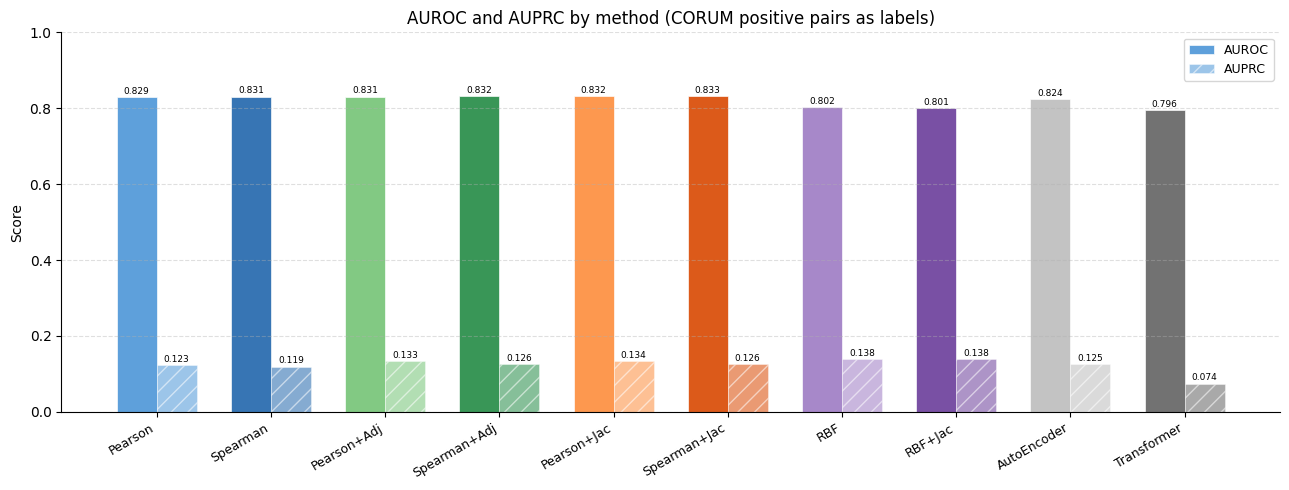

In [11]:
m = metrics_df.set_index("method").reindex(METHOD_ORDER).dropna(how="all")
methods_present = m.index.tolist()
labels_present  = [LABELS[m_] for m_ in methods_present]
colors_present  = [COLORS[m_] for m_ in methods_present]

x      = np.arange(len(methods_present))
width  = 0.35

fig, ax = plt.subplots(figsize=(13, 5))

bars_auroc = ax.bar(x - width/2, m["AUROC"],  width, color=colors_present, alpha=0.9,  label="AUROC",  edgecolor="white", linewidth=0.5)
bars_auprc = ax.bar(x + width/2, m["AUPRC"],  width, color=colors_present, alpha=0.55, label="AUPRC",  edgecolor="white", linewidth=0.5, hatch="//")

# Value labels on top of each bar
for bar in bars_auroc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=6.5)
for bar in bars_auprc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=6.5)

ax.set_xticks(x)
ax.set_xticklabels(labels_present, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("AUROC and AUPRC by method (CORUM positive pairs as labels)", fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/figures/eval_auroc_auprc.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2 — Precision@K and Enrichment@K curves

**Precision@K**: fraction of the top-K predicted pairs that are CORUM-positive.  
**Enrichment@K**: precision@K divided by the background CORUM-positive rate — how many times better than random.  
Both decay as K grows (the longer the ranked list the harder it is to stay precise). Methods that stay high longer are preferable for network construction.

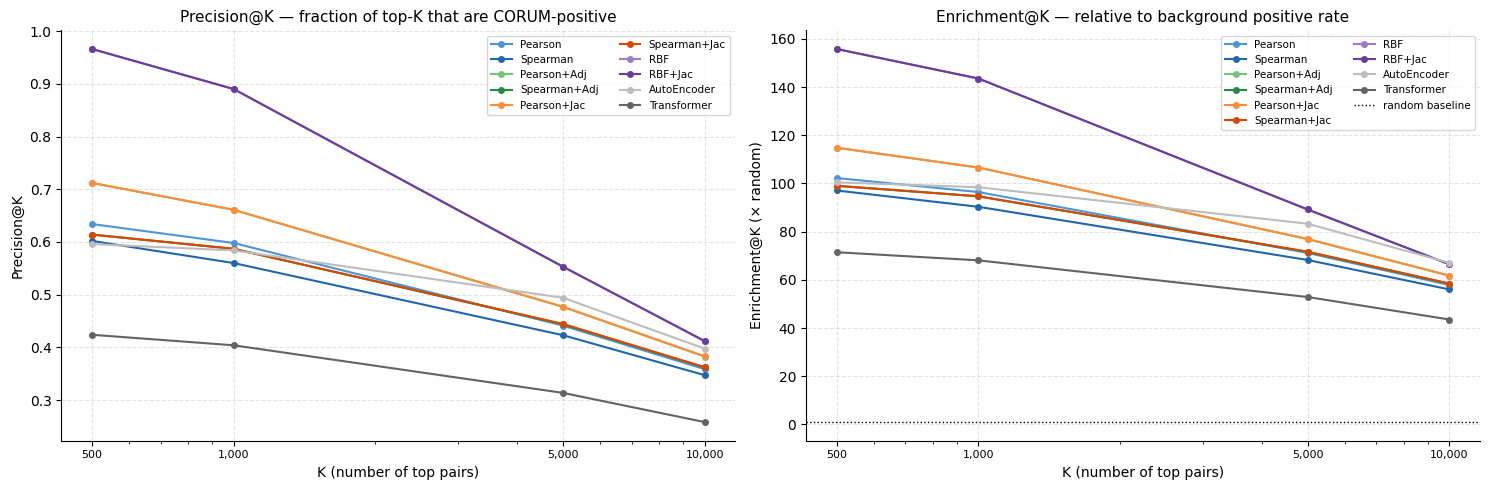

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for method in METHOD_ORDER:
    sub = atk_df[atk_df["method"] == method].sort_values("K")
    if sub.empty:
        continue
    kw = dict(color=COLORS[method], marker="o", markersize=4, linewidth=1.5, label=LABELS[method])
    axes[0].plot(sub["K"], sub["precision_at_K"],  **kw)
    axes[1].plot(sub["K"], sub["enrichment_at_K"], **kw)

for ax, ylabel, title in zip(
    axes,
    ["Precision@K", "Enrichment@K (× random)"],
    ["Precision@K — fraction of top-K that are CORUM-positive",
     "Enrichment@K — relative to background positive rate"],
):
    ax.set_xlabel("K (number of top pairs)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xscale("log")
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([f"{k:,}" for k in K_VALUES], fontsize=8)
    ax.grid(linestyle="--", alpha=0.35)
    ax.spines[["top","right"]].set_visible(False)

axes[1].axhline(1.0, color="black", linestyle=":", linewidth=1, label="random baseline")
axes[0].legend(fontsize=7.5, ncol=2, loc="upper right")
axes[1].legend(fontsize=7.5, ncol=2, loc="upper right")

plt.tight_layout()
plt.savefig("../outputs/figures/eval_precision_enrichment_at_k.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 3 — Score separation: positive vs background

For each method, the mean score of CORUM-positive pairs (known co-complex) vs all background pairs.
A larger gap means the method more cleanly separates true interactions from non-interactions.

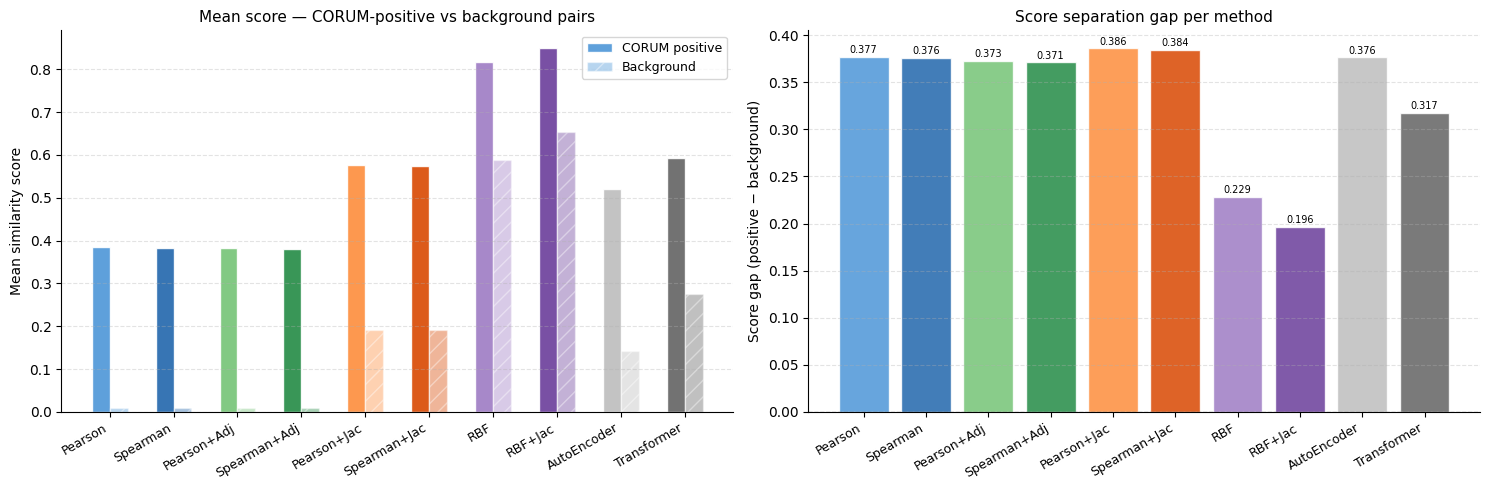

In [13]:
m = metrics_df.set_index("method").reindex(METHOD_ORDER).dropna(how="all")
methods_present = m.index.tolist()
labels_present  = [LABELS[m_] for m_ in methods_present]
colors_present  = [COLORS[m_] for m_ in methods_present]

pos_means = m["mean_positive_score"].values
bg_means  = m["mean_background_score"].values
gaps      = pos_means - bg_means

x     = np.arange(len(methods_present))
width = 0.28

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: raw mean scores side by side
axes[0].bar(x - width/2, pos_means, width, color=colors_present, alpha=0.9,  label="CORUM positive", edgecolor="white")
axes[0].bar(x + width/2, bg_means,  width, color=colors_present, alpha=0.4,  label="Background",     edgecolor="white", hatch="//")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_present, rotation=30, ha="right", fontsize=9)
axes[0].set_ylabel("Mean similarity score")
axes[0].set_title("Mean score — CORUM-positive vs background pairs", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", linestyle="--", alpha=0.35)
axes[0].spines[["top","right"]].set_visible(False)

# Right: absolute gap (positive mean − background mean)
bar_gap = axes[1].bar(x, gaps, color=colors_present, alpha=0.85, edgecolor="white")
for bar, gap in zip(bar_gap, gaps):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{gap:.3f}", ha="center", va="bottom", fontsize=7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_present, rotation=30, ha="right", fontsize=9)
axes[1].set_ylabel("Score gap (positive − background)")
axes[1].set_title("Score separation gap per method", fontsize=11)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].grid(axis="y", linestyle="--", alpha=0.35)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/figures/eval_score_separation.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 4 — Complex-level z-score distribution

For each CORUM complex, the mean within-complex similarity is compared to size-matched random protein sets (z-score). A high z-score means the method assigns much higher scores to known complex members than to random protein sets of the same size. The box plot shows the distribution across all 1,944 complexes evaluated.

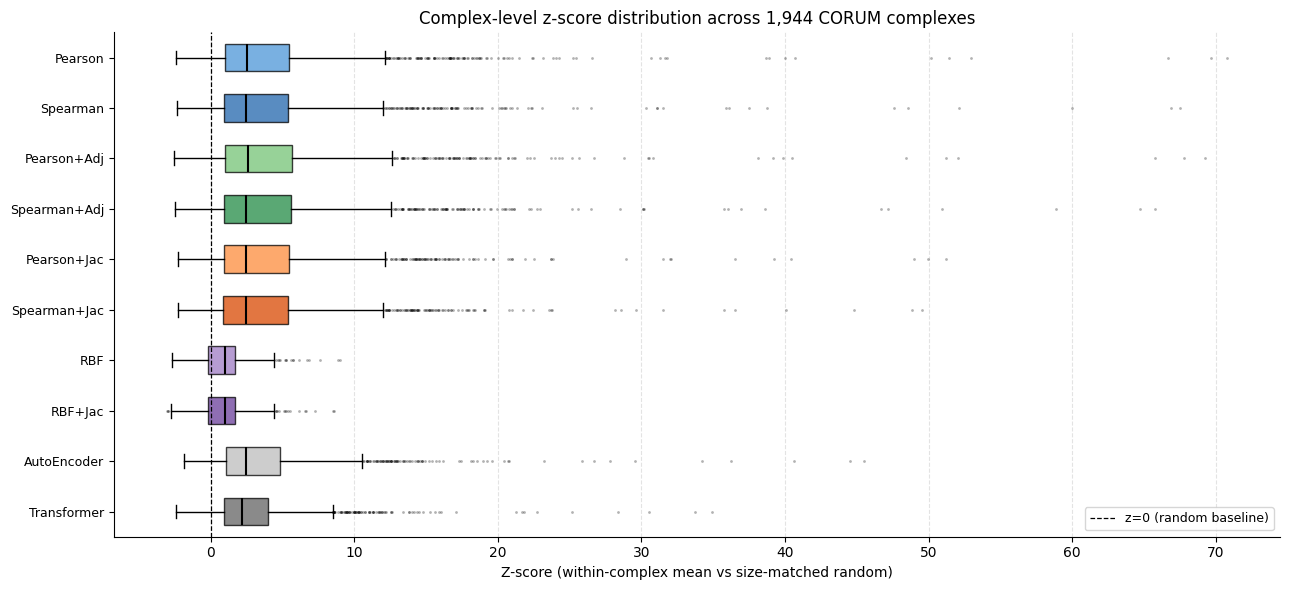

: 

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

# Collect z-scores per method in METHOD_ORDER, bottom-to-top on y-axis
plot_data   = []
plot_labels = []
plot_colors = []

for method in reversed(METHOD_ORDER):   # reversed → first method at top
    sub = complex_df[complex_df["method"] == method]["z_score"].dropna()
    if sub.empty:
        continue
    plot_data.append(sub.values)
    plot_labels.append(LABELS[method])
    plot_colors.append(COLORS[method])

bp = ax.boxplot(
    plot_data,
    vert=False,
    patch_artist=True,
    notch=False,
    widths=0.55,
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

for patch, color in zip(bp["boxes"], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_yticks(range(1, len(plot_labels) + 1))
ax.set_yticklabels(plot_labels, fontsize=9)
ax.axvline(0, color="black", linestyle="--", linewidth=0.9, label="z=0 (random baseline)")
ax.set_xlabel("Z-score (within-complex mean vs size-matched random)", fontsize=10)
ax.set_title("Complex-level z-score distribution across 1,944 CORUM complexes", fontsize=12)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/figures/eval_complex_zscore.png", dpi=150, bbox_inches="tight")
plt.show()